In [2]:
import pyodbc , pandas as pd , numpy as np
import matplotlib.pyplot as plt , seaborn as sns
import os
os.system('cls')
import warnings
warnings.filterwarnings('ignore')
# Simple SQL Server connection with pandas
server = 'LAPTOP-O2H5FU1M\\SQLEXPRESS'
database = 'Testdb'

try:
    # Connect to SQL Server
    conn = pyodbc.connect(
        f'DRIVER={{ODBC Driver 17 for SQL Server}};'
        f'SERVER={server};'
        f'DATABASE={database};'
        f'Trusted_Connection=yes;'
    )
    
    print("✅ Connected to SQL Server!")
    
    # Example 1: Simple query to pandas DataFrame
    QUERY = "SELECT *  FROM Mydatasheet"
    Raw_DF = pd.read_sql(QUERY, conn)
    print("\n📊 Databases:")
    display(Raw_DF)
    

    
    # Close connection
    conn.close()
    print("\n✅ Connection closed")
    
except Exception as e:
    print(f"❌ Error: {e}")

✅ Connected to SQL Server!

📊 Databases:


,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly



✅ Connection closed


In [2]:
print(f'''The columns is : {Raw_DF.shape[1]} which contains of\n {Raw_DF.columns} 

and row of this datasheet is  : {Raw_DF.shape[0]}  and it contains {Raw_DF.index}

and the null cell is {Raw_DF.isnull().sum().sum()}''')

The columns is : 19 which contains of
 Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_Amount_USD', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Payment_Method',
       'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used',
       'Previous_Purchases', 'Preferred_Payment_Method',
       'Frequency_of_Purchases'],
      dtype='object') 

and row of this datasheet is  : 3900  and it contains RangeIndex(start=0, stop=3900, step=1)

and the null cell is 0


In [3]:

print("1- Column Nunberical Data Types are:")
for col in Raw_DF.columns:
    if Raw_DF[col].dtype != 'object':  print(col , end="  ")
        
   

obj = []

print("\n\n2-Column Categorical Data Types are:")
for col in Raw_DF.columns:
    if Raw_DF[col].dtype == 'object': obj.append(col)  # Each row: [col name, dtype]

obj = np.array(obj)
# Reshape into rows and columns (e.g., 2 columns, as an example)
# If you want 2 columns:
n_cols = 7

# print( len(obj),np.ceil(len(obj)/n_cols))

n_rowms = int(np.ceil(len(obj) / n_cols))
# print(n_rows)
reshaped_obj = obj.reshape(n_rowms, n_cols) if len(obj) % n_cols == 0 else print("Error: Number of columns does not divide the number of elements evenly")
print(reshaped_obj)



1- Column Nunberical Data Types are:
Customer_ID  Age  Purchase_Amount_USD  Review_Rating  Previous_Purchases  

2-Column Categorical Data Types are:
[['Gender' 'Item_Purchased' 'Category' 'Location' 'Size' 'Color' 'Season']
 ['Subscription_Status' 'Payment_Method' 'Shipping_Type'
  'Discount_Applied' 'Promo_Code_Used' 'Preferred_Payment_Method'
  'Frequency_of_Purchases']]


In [59]:
def analyze_categorical_columns_return(df):
    results = {}
    
    for column in df.columns:
        if df[column].dtype == 'O':  # Object type (categorical)
            # Get basic stats
            duplicates = df[column].duplicated().sum()
            unique_count = df[column].nunique()
            counts = df[column].value_counts()
            
            # Create value counts DataFrame
            counts_df = counts.reset_index()
            counts_df.columns = [f"{column}_Value", "Count"]
            
            # Store results
            results[column] = {
                'duplicates': duplicates,
                'unique_values': unique_count,
                'value_counts_df': counts_df 
            }
    
    return results

    # Get all results
results = analyze_categorical_columns_return(Raw_DF)
# print(results['duplicates'])

# Access specific column results

for col in Raw_DF.columns :
    if Raw_DF[col].dtype == 'O' : 
        display(results[col]['value_counts_df']) 



,Gender_Value,Count
0,Male,2652
1,Female,1248


,Item_Purchased_Value,Count
0,Blouse,171
1,Jewelry,171
2,Pants,171
3,Shirt,169
4,Dress,166
5,Sweater,164
6,Jacket,163
7,Belt,161
8,Sunglasses,161
9,Coat,161


,Category_Value,Count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


,Location_Value,Count
0,Montana,96
1,California,95
2,Idaho,93
3,Illinois,92
4,Alabama,89
5,Minnesota,88
6,Nebraska,87
7,New York,87
8,Nevada,87
9,Maryland,86


,Size_Value,Count
0,M,1755
1,L,1053
2,S,663
3,XL,429


...

,Shipping_Type_Value,Count
0,Free Shipping,675
1,Standard,654
2,Store Pickup,650
3,Next Day Air,648
4,Express,646
5,2-Day Shipping,627


,Discount_Applied_Value,Count
0,No,2223
1,Yes,1677


,Promo_Code_Used_Value,Count
0,No,2223
1,Yes,1677


,Preferred_Payment_Method_Value,Count
0,PayPal,677
1,Credit Card,671
2,Cash,670
3,Debit Card,636
4,Venmo,634
5,Bank Transfer,612


,Frequency_of_Purchases_Value,Count
0,Every 3 Months,584
1,Annually,572
2,Quarterly,563
3,Monthly,553
4,Bi-Weekly,547
5,Fortnightly,542
6,Weekly,539


  Subscription_Status_Value  Count
0                        No   2847
1                       Yes   1053
  Discount_Applied_Value  Count
0                     No   2223
1                    Yes   1677
  Promo_Code_Used_Value  Count
0                    No   2223
1                   Yes   1677


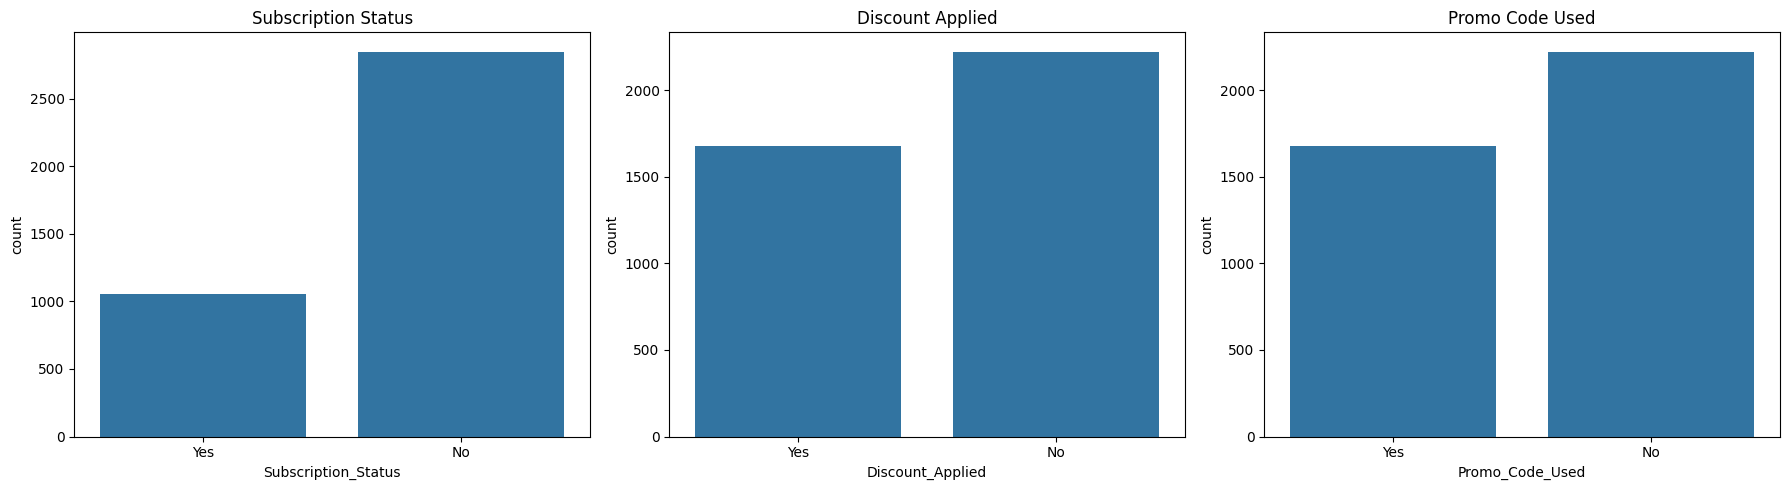

In [68]:
Subscription_Status_Value = results['Subscription_Status']['value_counts_df']
Discount_Applieds_Value = results['Discount_Applied']['value_counts_df']
Promo_Code_Used_Value = results['Promo_Code_Used']['value_counts_df']

print(Subscription_Status_Value)
print(Discount_Applieds_Value)
print(Promo_Code_Used_Value)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='Subscription_Status', data=Raw_DF, ax=axes[0])
axes[0].set_title('Subscription Status')

sns.countplot(x='Discount_Applied', data=Raw_DF, ax=axes[1])
axes[1].set_title('Discount Applied')

sns.countplot(x='Promo_Code_Used', data=Raw_DF, ax=axes[2])
axes[2].set_title('Promo Code Used')

plt.tight_layout()
plt.show()


In [74]:
Gender_values = results['Gender']['value_counts_df']
print(Gender_values)
Size_values = results['Size']['value_counts_df']
print(Size_values)


Season_values = results['Season']['value_counts_df']
print(Season_values)

category_counts = results['Category']['value_counts_df']
print(category_counts)


  Gender_Value  Count
0         Male   2652
1       Female   1248
  Size_Value  Count
0          M   1755
1          L   1053
2          S    663
3         XL    429
  Season_Value  Count
0       Spring    999
1         Fall    975
2       Winter    971
3       Summer    955
  Category_Value  Count
0       Clothing   1737
1    Accessories   1240
2       Footwear    599
3      Outerwear    324


In [ ]:

# plt.figure(figsize=(12, 6))
# ax = Gender_values.plot.bar(x='Gender_Value', y='Count', rot=45)
# ax.set_title('Gender Distribution')
# ax.set_xlabel('Gender')
# ax.set_ylabel('Count')
# plt.show()



plt.pie(category_counts['Count'], labels=category_counts['Category_Value'], autopct='%1.1f%%', startangle=140)

# Add a title
plt.title('Distribution of Categories')
plt.show()

plt.pie(Season_values['Count'], labels=Season_values['Season_Value'], autopct='%1.1f%%', startangle=140)

# Add a title
plt.title('Distribution of Seasons')
plt.show()

plt.pie(category_counts['Count'], labels=category_counts['Category_Value'], autopct='%1.1f%%', startangle=140)

# # Add a title
# plt.title('Distribution of Categories')



In [44]:
with pd.option_context('display.float_format', '{:.2f}'.format):
    display(Raw_DF.describe())

,Customer_ID,Age,Purchase_Amount_USD,Review_Rating,Previous_Purchases
count,3900.00,3900.00,3900.00,3900.00,3900.00
mean,1950.50,44.07,59.76,3.75,25.35
std,1125.98,15.21,23.69,0.72,14.45
min,1.00,18.00,20.00,2.50,1.00
25%,975.75,31.00,39.00,3.10,13.00
50%,1950.50,44.00,60.00,3.70,25.00
75%,2925.25,57.00,81.00,4.40,38.00
max,3900.00,70.00,100.00,5.00,50.00


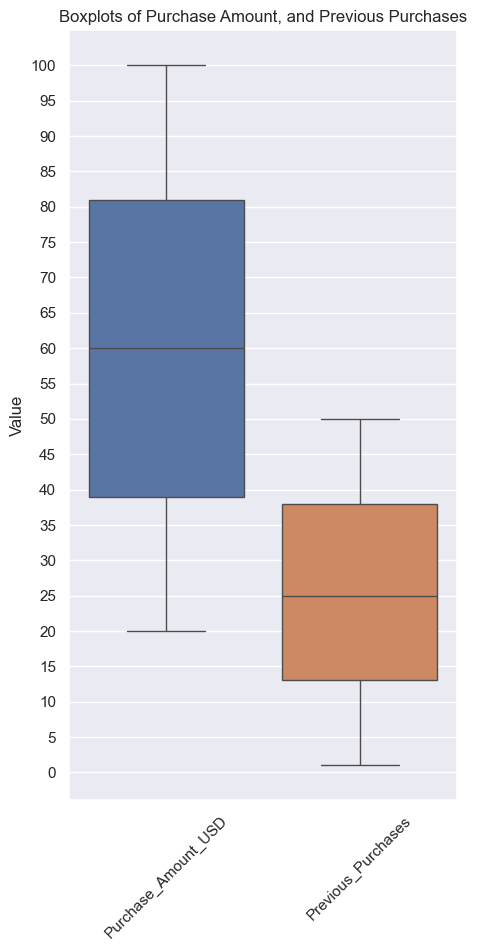

In [174]:
# Create a figure and axes
sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(5, 10))  # Adjust figure size as needed

# Create the boxplot
Purchase_df = Raw_DF[['Purchase_Amount_USD', 'Previous_Purchases']]
sns.boxplot(data=Purchase_df, ax=ax)

# Add a title
ax.set_title('Boxplots of Purchase Amount, and Previous Purchases')
ax.set_ylabel('Value')
ax.tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability

ax.set_yticks(range(0, 101, 5))




# Show the plot
plt.show()

,Category_Value,Count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


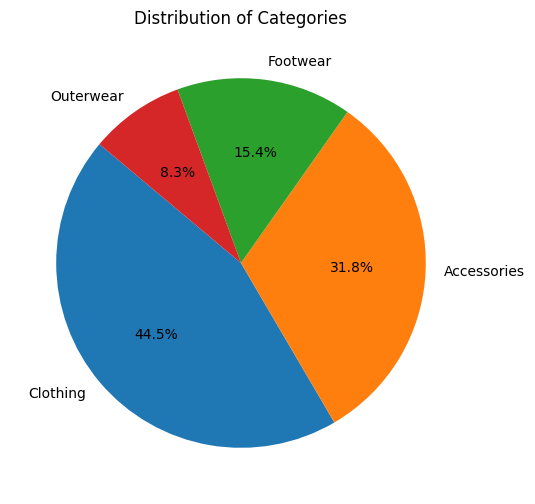

In [ ]:
display(category_counts)

# Create the pie chart
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
plt.pie(category_counts['Count'], labels=category_counts['Category_Value'], autopct='%1.1f%%', startangle=140)

# Add a title
plt.title('Distribution of Categories')

# Show the plot
plt.show()

Duplicates in Gender: 3898
  Gender_Value  Count
0         Male   2652
1       Female   1248


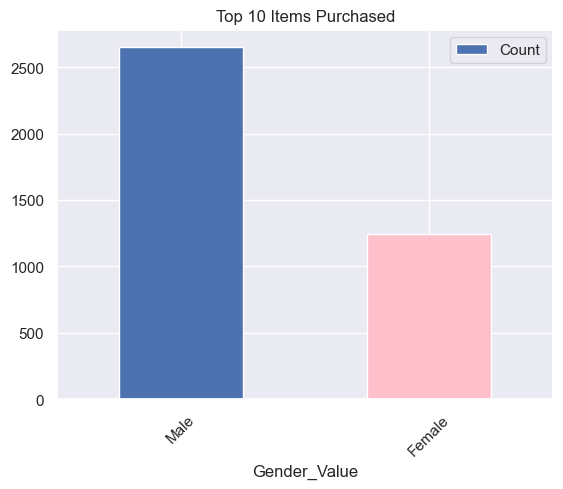

In [175]:
gender_results = results['Gender']
print(f"Duplicates in Gender: {gender_results['duplicates']}")

Gender_df = gender_results['value_counts_df']
print(Gender_df)

ax = gender_results['value_counts_df'].plot.bar(x='Gender_Value', y='Count', rot=45)

for i, label in enumerate(ax.get_xticklabels()):
    if label.get_text() == 'Female':
        ax.patches[i].set_facecolor('pink')

plt.title('Top 10 Items Purchased')
plt.show()

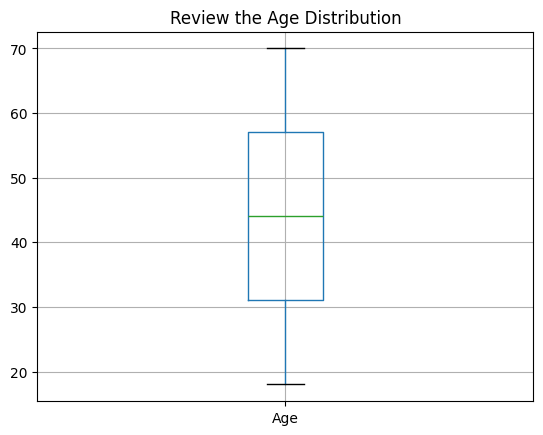

In [57]:
Raw_DF.boxplot(column='Age')
plt.title('Review the Age Distribution')
plt.suptitle('')
plt.show()

In [41]:
import plotly.express as px

palette = {'Male': 'darkblue', 'Female': 'darkred'}

fig = px.histogram(Raw_DF, x="Age", color="Gender",
                   color_discrete_map=palette, nbins=5)
fig.show()

<Axes: xlabel='Age', ylabel='Count'>

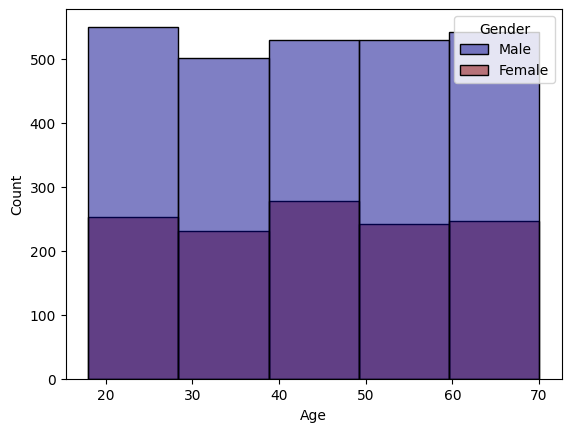

In [35]:

palette = {'Male': 'darkblue', 'Female': 'darkred'}
sns.histplot(data=Raw_DF, x='Age', hue = 'Gender' , palette=palette ,bins = 5)

In [40]:
# ...existing code...

import plotly.graph_objects as go

genders = ['Male', 'Female']
colors = {'Male': 'darkblue', 'Female': 'darkred'}
bins = 5

data = []
bar_width = 30  # Increase this value for thicker bars (default was 15)

for i, gender in enumerate(genders):
    ages = Raw_DF[Raw_DF['Gender'] == gender]['Age'].dropna()
    hist, bin_edges = np.histogram(ages, bins=bins)
    x = (bin_edges[:-1] + bin_edges[1:]) / 2  # Bin centers
    y = np.full_like(x, i)  # Numeric y for gender
    z = np.zeros_like(hist)
    dz = hist

    # Simulate 3D bars using Scatter3d (vertical lines)
    for xi, yi, zi, dzi in zip(x, y, z, dz):
        data.append(go.Scatter3d(
            x=[xi, xi],
            y=[yi, yi],
            z=[zi, dzi],
            mode='lines',
            line=dict(color=colors[gender], width=bar_width),  # Increased width here
            name=gender if zi == 0 else None,
            showlegend=bool(zi == 0)
        ))

fig = go.Figure(data=data)
fig.update_layout(
    scene=dict(
        xaxis_title='Age',
        yaxis=dict(
            tickvals=[0, 1],
            ticktext=genders,
            title='Gender'
        ),
        zaxis_title='Count'
    ),
    title='3D Histogram of Age by Gender',
    legend_title='Gender'
)
fig.show()
# ...existing code...

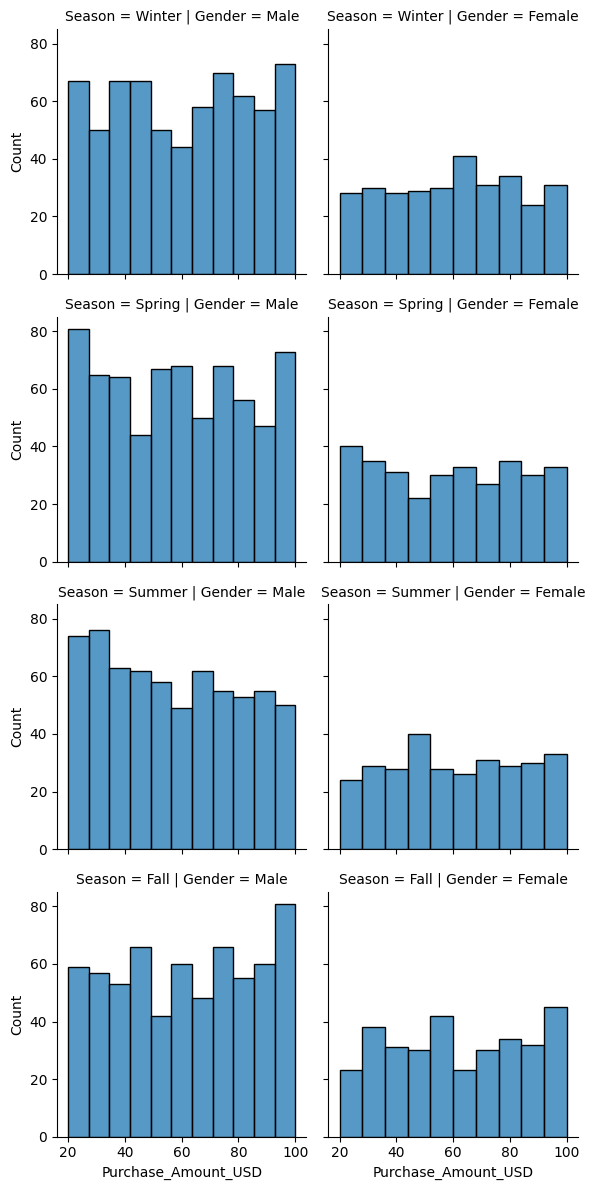

In [117]:
g = sns.FacetGrid(Raw_DF, col="Gender", row="Season")
g.map(sns.histplot, "Purchase_Amount_USD")
plt.show()

In [ ]:
grouped = Raw_DF.groupby('Gender')
# Create separate DataFrames for males and females
male_df = grouped.get_group('Male')
female_df = grouped.get_group('Female')

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2647,2648,60,Male,Shoes,Footwear,58,South Carolina,M,Red,Summer,3.3,No,Debit Card,2-Day Shipping,No,No,25,Debit Card,Annually
2648,2649,51,Male,Pants,Clothing,84,Illinois,M,Gray,Spring,3.9,No,Venmo,Next Day Air,No,No,14,PayPal,Bi-Weekly
2649,2650,23,Male,Gloves,Accessories,21,Minnesota,M,Magenta,Fall,3.9,No,Credit Card,Store Pickup,No,No,14,Bank Transfer,Fortnightly
2650,2651,20,Male,Socks,Clothing,35,Oregon,L,Maroon,Summer,4.2,No,PayPal,Standard,No,No,46,Credit Card,Every 3 Months


In [17]:
display(female_df)


NameError: name 'female_df' is not defined

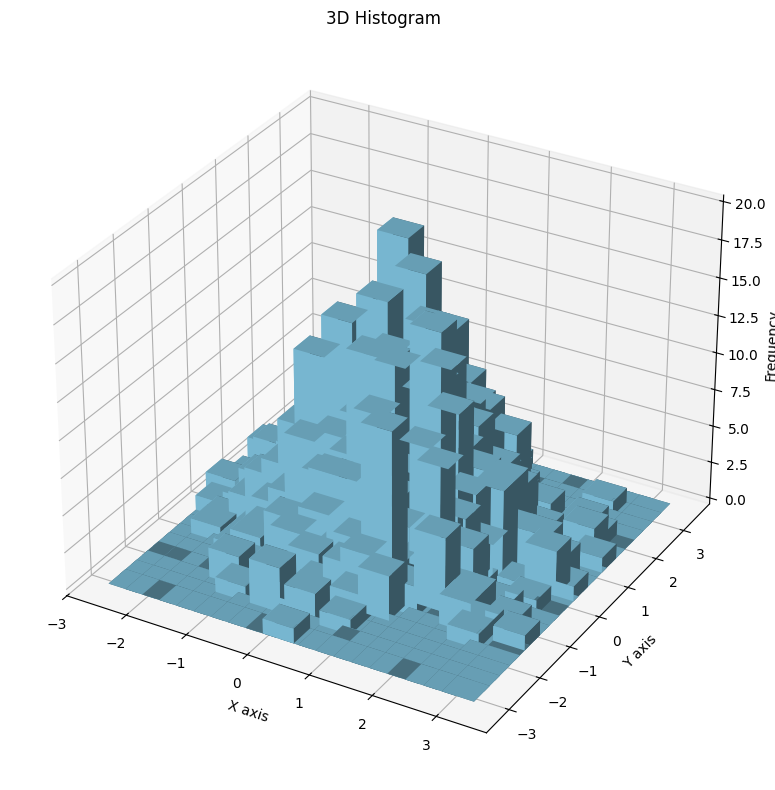

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure and 3D axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Generate random data
x = np.random.normal(0, 1, 1000)
y = np.random.normal(0, 1, 1000)
z = np.random.normal(0, 1, 1000)

# Create histogram bins
hist, xedges, yedges = np.histogram2d(x, y, bins=20)
xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0

# Construct arrays with the dimensions for the 16 bars.
dx = dy = 0.5 * np.ones_like(zpos)
dz = hist.ravel()

# Plot the 3D histogram bars
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, zsort='average', color='skyblue')

# Add labels and title
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Frequency')
ax.set_title('3D Histogram')

plt.tight_layout()
plt.show()